In [2]:
# ============================================================
# Google Drive is mounted so that processed data can be stored
# persistently. This ensures the working sample survives Colab
# session resets and does not need to be re-downloaded.
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ============================================================
# 01 - DATA COLLECTION
# Installing the HuggingFace 'datasets' library, which gives us
# direct access to the McAuley Amazon Reviews 2023 dataset.
# The '-q' flag keeps the install output quiet and tidy.
# ============================================================

!pip install datasets -q

In [ ]:
# ============================================================
# A dedicated project folder is created in Google Drive to
# store the dataset persistently. The Home & Kitchen reviews
# file is then downloaded from HuggingFace. Storing the file
# in Drive ensures it survives future Colab session resets.
# ============================================================

import os
from huggingface_hub import hf_hub_download

# The project folder is created in Google Drive if it does not exist
drive_folder = "/content/drive/MyDrive/MSc-Project/data"
os.makedirs(drive_folder, exist_ok=True)

# The Home & Kitchen reviews file is downloaded from HuggingFace
file_path = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename="raw/review_categories/Home_and_Kitchen.jsonl",
    repo_type="dataset"
)

print("Downloaded to:", file_path)

raw/review_categories/Home_and_Kitchen.j(…):   0%|          | 0.00/31.4G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [5]:
# ============================================================
# The full file is approximately 31 GB and too large to load
# into memory at once. The file is therefore read line by line
# and a sample of 100,000 reviews is taken as a working subset.
# The sample is saved to Google Drive so that it persists across
# Colab session resets and can be reloaded instantly, removing
# any need to re-download the full dataset.
# ============================================================

import pandas as pd
import json

sample_size = 100000
rows = []

# The file is read line by line and parsed until the sample size is reached
with open(file_path, "r") as f:
    for i, line in enumerate(f):
        if i >= sample_size:
            break
        rows.append(json.loads(line))

reviews_df = pd.DataFrame(rows)

# The working sample is saved to Google Drive in CSV format
output_path = "/content/drive/MyDrive/MSc-Project/data/home_kitchen_sample_100k.csv"
reviews_df.to_csv(output_path, index=False)

print("Sample loaded:", reviews_df.shape)
print("Saved to:", output_path)
reviews_df.head()

NameError: name 'file_path' is not defined

In [11]:
# ============================================================
# For future sessions, the working sample can be reloaded
# directly from Google Drive, removing any need to download or
# process the full dataset again. This cell confirms the saved
# sample can be read back successfully.
# ============================================================

import pandas as pd

sample_path = "/content/drive/MyDrive/MSc-Project/home_kitchen_sample_100k.csv"
reviews_df = pd.read_csv(sample_path)

print("Sample reloaded from Drive:", reviews_df.shape)
reviews_df.head()

Sample reloaded from Drive: (100000, 10)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1.0,Received Used & scratched item! Purchased new!,Livid. Once again received an obviously used ...,[],B007WQ9YNO,B09XWYG6X1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1677373409298,1,True
1,5.0,Excellent for moving & storage & floods!,I purchased these for multiple reasons. The ma...,[],B09H2VJW6K,B0BXDLF8TW,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1672043410846,0,True
2,2.0,Lid very loose- needs a gasket imo. Small base.,[[VIDEOID:c87e962bc893a948856b0f1b285ce6cc]] I...,[{'small_image_url': 'https://m.media-amazon.c...,B07RL297VR,B09G2PW8ZG,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1653447296788,0,True
3,5.0,Best purchase ever!,If you live at a higher elevation like me (5k ...,[{'small_image_url': 'https://m.media-amazon.c...,B09CQF4SWV,B08CSZDXZY,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1651855096178,0,True
4,5.0,Excellent for yarn!,I use these to store yarn. They easily hold 12...,[{'small_image_url': 'https://images-na.ssl-im...,B003U6A3EY,B0C6V27S6N,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1589934525940,1,True


# **EDA - Verified Vs Unverified**

In [12]:
# ============================================================
# VERIFIED VS UNVERIFIED REVIEWS — INITIAL DISTRIBUTION
# Following supervisor guidance, the verified_purchase field is
# examined to establish the balance between verified and
# unverified reviews within the sample. Establishing this split
# is a necessary first step before assessing whether unverified
# reviews introduce bias into the subsequent text analysis.
# ============================================================

# The distribution of verified and unverified reviews is counted
verified_counts = reviews_df["verified_purchase"].value_counts()
verified_pct = reviews_df["verified_purchase"].value_counts(normalize=True) * 100

print("Review counts by verification status:")
print(verified_counts)
print("\nPercentage split:")
print(verified_pct.round(2))

Review counts by verification status:
verified_purchase
True     70852
False    29148
Name: count, dtype: int64

Percentage split:
verified_purchase
True     70.85
False    29.15
Name: proportion, dtype: float64


In [13]:
# ============================================================
# VERIFIED VS UNVERIFIED — COMPARISON OF KEY CHARACTERISTICS
#
# The two groups are compared across rating, review length, and
# helpful votes to determine whether unverified reviews differ
# systematically from verified ones. Review length is derived
# from the review text as a proxy for the depth of feedback,
# which is relevant to the subsequent NLP analysis.
# ============================================================

# Review length is derived as the character count of the review text
reviews_df["review_length"] = reviews_df["text"].astype(str).str.len()

# Word count is also derived as a secondary measure of review depth
reviews_df["word_count"] = reviews_df["text"].astype(str).str.split().str.len()

# The groups are compared across the selected characteristics
comparison = reviews_df.groupby("verified_purchase").agg(
    review_count=("rating", "size"),
    mean_rating=("rating", "mean"),
    median_rating=("rating", "median"),
    mean_length=("review_length", "mean"),
    mean_words=("word_count", "mean"),
    mean_helpful_votes=("helpful_vote", "mean")
).round(2)

print("Comparison of verified and unverified reviews:")
comparison

Comparison of verified and unverified reviews:


,review_count,mean_rating,median_rating,mean_length,mean_words,mean_helpful_votes
verified_purchase,,,,,,
False,29148,4.48,5.0,633.42,117.62,1.87
True,70852,4.36,5.0,217.61,40.82,1.41


In [14]:
# ============================================================
# STATISTICAL SIGNIFICANCE TESTING
#
# Independent t-tests and Mann-Whitney U tests are applied to
# determine whether the observed differences between verified
# and unverified reviews are statistically significant. The
# Mann-Whitney U test is included as a non-parametric
# alternative, since review length is unlikely to be normally
# distributed.
# ============================================================

from scipy import stats

verified = reviews_df[reviews_df["verified_purchase"] == True]
unverified = reviews_df[reviews_df["verified_purchase"] == False]

# Each characteristic is tested for a significant difference between groups
for col in ["rating", "review_length", "word_count", "helpful_vote"]:
    t_stat, t_p = stats.ttest_ind(verified[col], unverified[col], equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(verified[col], unverified[col], alternative="two-sided")
    print(f"{col}:")
    print(f"   t-test p-value        = {t_p:.2e}")
    print(f"   Mann-Whitney p-value  = {u_p:.2e}")
    print(f"   Significant (p<0.05)  = {t_p < 0.05}")
    print()

rating:
   t-test p-value        = 6.56e-68
   Mann-Whitney p-value  = 3.09e-02
   Significant (p<0.05)  = True

review_length:
   t-test p-value        = 0.00e+00
   Mann-Whitney p-value  = 0.00e+00
   Significant (p<0.05)  = True

word_count:
   t-test p-value        = 0.00e+00
   Mann-Whitney p-value  = 0.00e+00
   Significant (p<0.05)  = True

helpful_vote:
   t-test p-value        = 1.49e-02
   Mann-Whitney p-value  = 2.16e-32
   Significant (p<0.05)  = True



In [15]:
# ============================================================
# EFFECT SIZE ANALYSIS
#
# Given the large sample size, statistical significance alone is
# insufficient, as trivial differences become significant at
# scale. Cohen's d is therefore calculated to quantify the
# practical magnitude of each difference. Conventional
# thresholds are: 0.2 small, 0.5 medium, 0.8 large.
# ============================================================

import numpy as np

def cohens_d(group1, group2):
    # The pooled standard deviation is calculated
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_sd

print("Effect sizes (Cohen's d) — verified vs unverified:\n")

for col in ["rating", "review_length", "word_count", "helpful_vote"]:
    d = cohens_d(verified[col], unverified[col])
    magnitude = ("negligible" if abs(d) < 0.2 else
                 "small" if abs(d) < 0.5 else
                 "medium" if abs(d) < 0.8 else "large")
    print(f"{col:16s} d = {d:+.3f}  ({magnitude})")

Effect sizes (Cohen's d) — verified vs unverified:

rating           d = -0.109  (negligible)
review_length    d = -0.927  (large)
word_count       d = -0.929  (large)
helpful_vote     d = -0.022  (negligible)


In [10]:
# ============================================================
# SUMMARY COMPARISON TABLE
#
# The results of the descriptive, significance, and effect size
# analyses are consolidated into a single summary table. The
# table is exported to CSV for direct inclusion in the
# dissertation. Presenting the p-value alongside Cohen's d
# allows statistical significance and practical significance to
# be distinguished clearly.
# ============================================================

# The interpretation thresholds for Cohen's d are defined
def interpret_d(d):
    d = abs(d)
    if d < 0.2:
        return "Negligible"
    elif d < 0.5:
        return "Small"
    elif d < 0.8:
        return "Medium"
    else:
        return "Large"

# Readable labels are assigned to each variable
labels = {
    "rating": "Rating (stars)",
    "review_length": "Review length (characters)",
    "word_count": "Word count",
    "helpful_vote": "Helpful votes"
}

summary_rows = []

for col, label in labels.items():
    # The group means are calculated
    mean_v = verified[col].mean()
    mean_u = unverified[col].mean()

    # The significance test is repeated for the summary
    _, p_val = stats.ttest_ind(verified[col], unverified[col], equal_var=False)

    # The effect size is calculated
    d = cohens_d(verified[col], unverified[col])

    summary_rows.append({
        "Variable": label,
        "Verified (mean)": round(mean_v, 2),
        "Unverified (mean)": round(mean_u, 2),
        "p-value": "< 0.001" if p_val < 0.001 else f"{p_val:.3f}",
        "Cohen's d": round(abs(d), 2),
        "Interpretation": interpret_d(d)
    })

summary_table = pd.DataFrame(summary_rows)

# The table is exported to CSV for use in the dissertation
table_path = "/content/drive/MyDrive/MSc-Project/outputs/verified_comparison_table.csv"
summary_table.to_csv(table_path, index=False)

print("Summary comparison of verified and unverified reviews")
print(f"n = {len(verified):,} verified; {len(unverified):,} unverified\n")
print("Table saved to:", table_path)

summary_table

Summary comparison of verified and unverified reviews
n = 70,852 verified; 29,148 unverified

Table saved to: /content/drive/MyDrive/MSc-Project/outputs/verified_comparison_table.csv


,Variable,Verified (mean),Unverified (mean),p-value,Cohen's d,Interpretation
0,Rating (stars),4.36,4.48,< 0.001,0.11,Negligible
1,Review length (characters),217.61,633.42,< 0.001,0.93,Large
2,Word count,40.82,117.62,< 0.001,0.93,Large
3,Helpful votes,1.41,1.87,0.015,0.02,Negligible


In [16]:
# ============================================================
# RATING DISTRIBUTION COMPARISON
#
# Mean values alone can mask differences in distribution shape.
# The proportion of reviews at each star rating is therefore
# compared across the two groups to establish whether unverified
# reviews are disproportionately concentrated at the extremes,
# which would carry implications for sentiment analysis.
# ============================================================

# The percentage of reviews at each star rating is calculated per group
dist = pd.crosstab(
    reviews_df["rating"],
    reviews_df["verified_purchase"],
    normalize="columns"
) * 100

dist.columns = ["Unverified %", "Verified %"]
dist["Difference"] = (dist["Unverified %"] - dist["Verified %"]).round(2)

print("Rating distribution by verification status:")
dist.round(2)

Rating distribution by verification status:


,Unverified %,Verified %,Difference
rating,,,
1.0,2.55,6.62,-4.07
2.0,2.53,4.09,-1.56
3.0,6.62,6.96,-0.33
4.0,21.18,11.73,9.45
5.0,67.11,70.60,-3.49


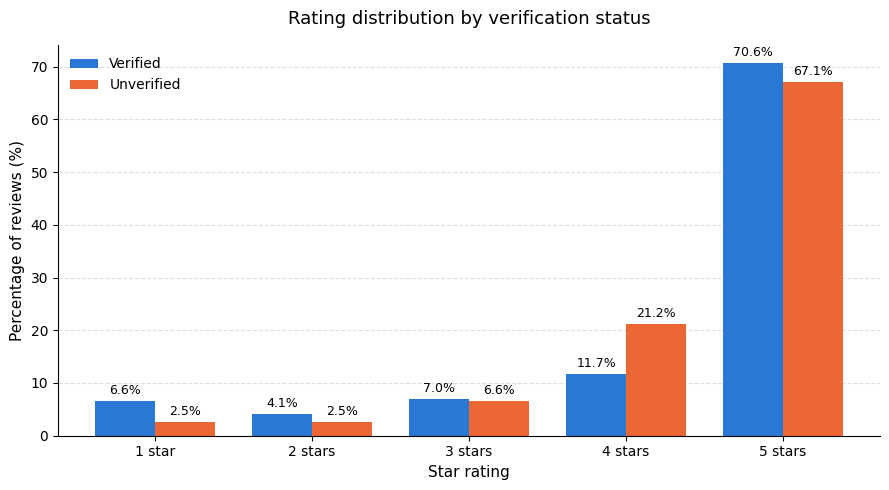

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/rating_distribution.png


In [17]:
# ============================================================
# VISUALISATION OF RATING DISTRIBUTION
#
# The rating distribution is plotted as a grouped bar chart to
# make the difference in complaint rates visually evident. The
# figure is saved to Google Drive for inclusion in the
# dissertation. A grouped format is used so that the proportion
# at each star rating can be compared directly between the two
# groups.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# The percentage distribution is recalculated for plotting
plot_data = pd.crosstab(
    reviews_df["rating"],
    reviews_df["verified_purchase"],
    normalize="columns"
) * 100

ratings = plot_data.index.astype(int)
unverified_pct = plot_data[False].values
verified_pct = plot_data[True].values

# Bar positions are offset so the two groups appear side by side
x = np.arange(len(ratings))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, verified_pct, width,
               label="Verified", color="#2a78d6")
bars2 = ax.bar(x + width/2, unverified_pct, width,
               label="Unverified", color="#eb6834")

# Each bar is labelled with its percentage value
for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}%",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Star rating", fontsize=11)
ax.set_ylabel("Percentage of reviews (%)", fontsize=11)
ax.set_title("Rating distribution by verification status",
             fontsize=13, pad=15)
ax.set_xticks(x)
ax.set_xticklabels([f"{r} star" if r == 1 else f"{r} stars" for r in ratings])
ax.legend(frameon=False)

# Gridlines are added on the y-axis only to aid readability
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

# The figure is saved to Google Drive for use in the dissertation
figure_path = "/content/drive/MyDrive/MSc-Project/outputs/rating_distribution.png"
import os
os.makedirs("/content/drive/MyDrive/MSc-Project/outputs", exist_ok=True)
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()
print("Figure saved to:", figure_path)

In [18]:
# ============================================================
# PREPROCESSING DECISION AND DATA PARTITIONING
#
# The analysis established that unverified reviews are
# substantially longer (Cohen's d = 0.93) but contain
# proportionally fewer strongly negative ratings (2.55% one-star
# versus 6.62% for verified reviews). As the sentiment gap
# component of the framework depends on the reliable detection
# of customer complaints, verified reviews are adopted as the
# primary corpus. Unverified reviews are retained as a
# comparison set rather than discarded, enabling the influence
# of verification status to be reported as a finding.
# ============================================================

# The dataset is partitioned by verification status
verified_df = reviews_df[reviews_df["verified_purchase"] == True].copy()
unverified_df = reviews_df[reviews_df["verified_purchase"] == False].copy()

# Both partitions are saved to Google Drive for use in later stages
verified_df.to_csv("/content/drive/MyDrive/MSc-Project/data/reviews_verified.csv", index=False)
unverified_df.to_csv("/content/drive/MyDrive/MSc-Project/data/reviews_unverified.csv", index=False)

print("Primary corpus (verified):   ", verified_df.shape)
print("Comparison set (unverified): ", unverified_df.shape)
print("\nBoth partitions saved to Google Drive.")

Primary corpus (verified):    (70852, 12)
Comparison set (unverified):  (29148, 12)

Both partitions saved to Google Drive.
